# **Day 91: Project 1 - Land Use / Land Cover Mapping (Part 3): The Map, Accuracy, Areas and Figures**
*Module 13 - Remote Sensing ML and Publication Projects*

The model is chosen (Day 90). Today we produce everything in the **Results** section:
1. the wall-to-wall **map** and a per-pixel **confidence** layer as GeoTIFFs
2. an **independent validation sample** (stratified random by map class), exported for interpretation
3. **Table 4**: OA, UA and PA with 95% CIs, and **bias-corrected class areas** with 95% CIs (RQ3)
4. the **area of applicability**
5. **interpretation**: grouped permutation importance and SHAP
6. post-processing (majority filter) and how to validate a map whose classes differ from the sampling strata
7. publication figures at 300 dpi and an auto-generated results paragraph

> The final model produces a wall-to-wall map. An independent validation sample then gives the map's accuracy and corrects the class areas, because simply counting mapped pixels is biased by classification errors.
>
> *Example:* The map shows 300 ha of mining, but the validation sample reveals that some mapped mining is really bare soil, so the corrected area is lower and has a confidence interval.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd, rasterio, json, sys, joblib, time
from pathlib import Path
from matplotlib.patches import Patch
from scipy.ndimage import uniform_filter
from sklearn.metrics import f1_score
import rs_utils as ru
ru.pub_style()

PROJ = Path("project1_lulc"); sys.path.insert(0, str(PROJ))
import lulc_features as lf
config = json.loads((PROJ / "config.json").read_text()); SEED = config["seed"]
meta = json.loads((PROJ / "models/final_model_meta.json").read_text())
model = joblib.load(PROJ / "models/final_model.joblib")
feats = meta["features"]; CLASSES = meta["classes"]; K = len(CLASSES)
print(f"final model: {meta['model']} | nested spatial-CV macro F1 {meta['nested_cv_macro_f1_pooled']:.3f} (95% CI {meta['nested_cv_macro_f1_ci95'][0]:.3f}-{meta['nested_cv_macro_f1_ci95'][1]:.3f})")

final model: XGBoost | nested spatial-CV macro F1 0.919 (95% CI 0.893-0.938)


## **1. Wall-to-Wall Prediction**
We rebuild the features with the **same module** used for training, predict class probabilities block by block (memory stays small for real scenes), and write two GeoTIFFs: the class map (`uint8`, with an embedded colour table) and the confidence (maximum class probability, in percent).

In [2]:
RAW = Path(config["raw_data_dir"])
F, fnames, fgroups, gap, profile = lf.build_feature_stack(RAW)
H, W = F.shape[1:]; T = profile["transform"]
cols_idx = [fnames.index(f) for f in feats]
proba = np.zeros((K, H, W), np.float32)
t0 = time.perf_counter()
for r0 in range(0, H, 100):                                                       # 100-row blocks
    Xb = F[cols_idx, r0:r0 + 100].reshape(len(cols_idx), -1).T
    proba[:, r0:r0 + 100] = model.predict_proba(Xb).T.reshape(K, -1, W) if hasattr(model, "predict_proba") else np.eye(K)[model.predict(Xb)].T.reshape(K, -1, W)
lc_map = proba.argmax(0).astype(np.uint8); conf = proba.max(0)
print(f"predicted {H * W:,} pixels in {time.perf_counter() - t0:.1f} s")

out = PROJ / "outputs"
ru.write_geotiff(out / "lulc_map_2024.tif", lc_map, T, nodata=255, dtype="uint8", band_names=["land_cover"])
with rasterio.open(out / "lulc_map_2024.tif", "r+") as dst:
    dst.write_colormap(1, {k: tuple(int(c[i:i + 2], 16) for i in (1, 3, 5)) + (255,) for k, c in enumerate(config["class_colors"])})
    dst.update_tags(classes=json.dumps(dict(enumerate(CLASSES))), model=meta["model"])
ru.write_geotiff(out / "lulc_confidence_2024.tif", np.round(conf * 100), T, nodata=255, dtype="uint8", band_names=["max_class_probability_pct"])
print({p.name: f"{p.stat().st_size / 1e3:.0f} kB" for p in out.glob("*.tif")})

predicted 250,000 pixels in 0.6 s
{'lulc_map_2024.tif': '28 kB', 'lulc_confidence_2024.tif': '119 kB'}


## **2. The Independent Validation Sample**
The training points were used to build and select the model, so they cannot validate the map. Following Day 88 and Olofsson et al. (2014), we draw a **new stratified random sample** with the map classes as strata, size it with Eq. 13, and give each rare class at least 75 points.

In a real study we export the points **without** the map label (to avoid interpreter bias), have two interpreters label them from very-high-resolution imagery for the map date, resolve disagreements, and read the labels back. Here, the simulated true land cover plays the interpreters' role.

In [3]:
counts = {k: int((lc_map == k).sum()) for k in range(K)}
W_i = np.array([counts[k] for k in range(K)]) / (H * W)
U_guess = np.full(K, 0.85)
n_total = int(np.ceil((np.sum(W_i * np.sqrt(U_guess * (1 - U_guess))) / config["validation"]["target_se_oa"]) ** 2))
rare = W_i < 0.05
alloc = np.where(rare, config["validation"]["n_rare_class"], 0)
alloc[~rare] = np.round((n_total - alloc.sum()) * W_i[~rare] / W_i[~rare].sum())
alloc = {k: int(a) for k, a in enumerate(alloc)}
vr, vc, vstrat = ru.stratified_random_sample(lc_map, alloc, seed=SEED + 1)
vx, vy = ru.pixel_centres(T, vr, vc)
val = gpd.GeoDataFrame({"val_id": np.arange(len(vr)), "stratum": vstrat, "row": vr, "col": vc, "reference": ""},
                       geometry=gpd.points_from_xy(vx, vy), crs=config["crs"])
val.sample(frac=1, random_state=SEED).drop(columns=["stratum"]).to_file(out / "validation_sample_for_interpretation.gpkg")   # blind: no map label
truth = rasterio.open(RAW / "_truth_landcover_SIMULATION_ONLY.tif").read(1)
val["reference"] = truth[vr, vc]                                                   # <- interpreters' labels in a real study
val["map"] = lc_map[vr, vc]
print(f"validation sample: n = {len(val)} (Eq. 13 target n = {n_total}); allocation {alloc}")
print(f"overlap with training pixels: {len(set(zip(vr, vc)) & set(zip(pd.read_csv(PROJ / 'data/training_table.csv')[['row', 'col']].itertuples(index=False))))} points")

validation sample: n = 1275 (Eq. 13 target n = 1275); allocation {0: 75, 1: 377, 2: 172, 3: 75, 4: 75, 5: 501}
overlap with training pixels: 0 points


## **3. Table 4: Accuracy and Area Estimates (RQ3)**

In [4]:
PIXEL_HA = config["pixel_size_m"] ** 2 / 1e4
summary, pmat = ru.olofsson_accuracy(val["map"].values, val["reference"].values, counts, PIXEL_HA, CLASSES)
table4 = summary.copy()
table4["TRUE_area_ha (simulation only)"] = np.bincount(truth.ravel(), minlength=K) * PIXEL_HA
table4.round(3).to_csv(out / "tables/table4_accuracy_area.csv", index=False)
pmat.round(5).to_csv(out / "tables/table4b_error_matrix_area_proportions.csv")
P = pmat.values; quantity = 0.5 * np.abs(P.sum(1) - P.sum(0)).sum(); allocation = 1 - np.trace(P) - quantity
print(f"OA = {summary.attrs['OA']:.3f} +/- {summary.attrs['OA_95CI']:.3f} (95% CI) | quantity disagreement {quantity:.3f}, allocation disagreement {allocation:.3f}")
print(f"TRUE map OA (simulation only): {(lc_map == truth).mean():.3f}")
table4.round(3)

OA = 0.952 +/- 0.012 (95% CI) | quantity disagreement 0.006, allocation disagreement 0.042
TRUE map OA (simulation only): 0.949


,class,mapped_area_ha,sample_n,UA,UA_95CI,PA,PA_95CI,adjusted_area_ha,area_95CI_ha,TRUE_area_ha (simulation only)
0,water,116.52,75,0.787,0.093,1.000,0.000,91.662,10.876,91.44
1,forest,3342.00,377,0.955,0.021,0.947,0.021,3368.788,103.608,3432.40
2,cropland,1521.80,172,0.971,0.025,0.949,0.030,1557.239,62.867,1528.56
3,built_up,271.24,75,0.973,0.037,1.000,0.000,264.007,9.957,269.64
4,mining_bare,302.36,75,0.947,0.051,0.972,0.029,294.511,17.803,296.40
5,shrub_grass,4446.08,501,0.946,0.020,0.951,0.017,4423.792,119.012,4381.56


The error matrix in **area proportions** (Table 4b) is the one to publish. Readers can derive any other measure from it. Also publish the matrix of **sample counts**, so that others can recompute the standard errors.

In [5]:
counts_matrix = pd.crosstab(pd.Categorical(val["map"], range(K)), pd.Categorical(val["reference"], range(K)), dropna=False)
counts_matrix.index = [f"map {c}" for c in CLASSES]; counts_matrix.columns = [f"ref {c}" for c in CLASSES]
counts_matrix.to_csv(out / "tables/table4c_error_matrix_sample_counts.csv"); counts_matrix

,ref water,ref forest,ref cropland,ref built_up,ref mining_bare,ref shrub_grass
map water,59,0,3,0,3,10
map forest,0,360,1,0,0,16
map cropland,0,0,167,0,0,5
map built_up,0,0,0,73,1,1
map mining_bare,0,0,1,0,71,3
map shrub_grass,0,20,7,0,0,474


## **4. Area of Applicability**

In [6]:
train = pd.read_csv(PROJ / "data/training_table.csv")
est = model.steps[-1][1] if hasattr(model, "steps") else model
if hasattr(est, "feature_importances_"):
    weights = est.feature_importances_
else:                                                                              # SVM / MLP / LR: permutation importance
    from sklearn.inspection import permutation_importance
    weights = np.clip(permutation_importance(model, train[feats].values, train["class_id"].values, n_repeats=3, random_state=SEED).importances_mean, 0, None) + 1e-6
X_full = F[cols_idx].reshape(len(cols_idx), -1).T
di, thr = ru.dissimilarity_index(train[feats].values, X_full, weights=weights, cv_folds=train["block"].values % 5)
aoa = (di <= thr).reshape(H, W)
ru.write_geotiff(out / "lulc_aoa_2024.tif", aoa.astype(np.uint8), T, dtype="uint8", band_names=["inside_AOA"])
print(f"{aoa.mean():.1%} of the area is inside the AOA (DI threshold {thr:.3f})")
in_val = aoa[vr, vc]
print(f"validation points inside AOA: {in_val.mean():.1%}; sample accuracy inside {np.mean(val['map'][in_val] == val['reference'][in_val]):.3f}"
      + (f", outside {np.mean(val['map'][~in_val] == val['reference'][~in_val]):.3f}" if (~in_val).sum() >= 10 else f", outside: only {(~in_val).sum()} points"))

99.7% of the area is inside the AOA (DI threshold 0.392)
validation points inside AOA: 99.1%; sample accuracy inside 0.945, outside 0.833


With a well-spread probability sample for training (as here), almost the whole area lies inside the AOA. The AOA becomes important with clustered training data (Day 88) or when the model is applied to another region or year.

## **5. Figure 6: The Map**

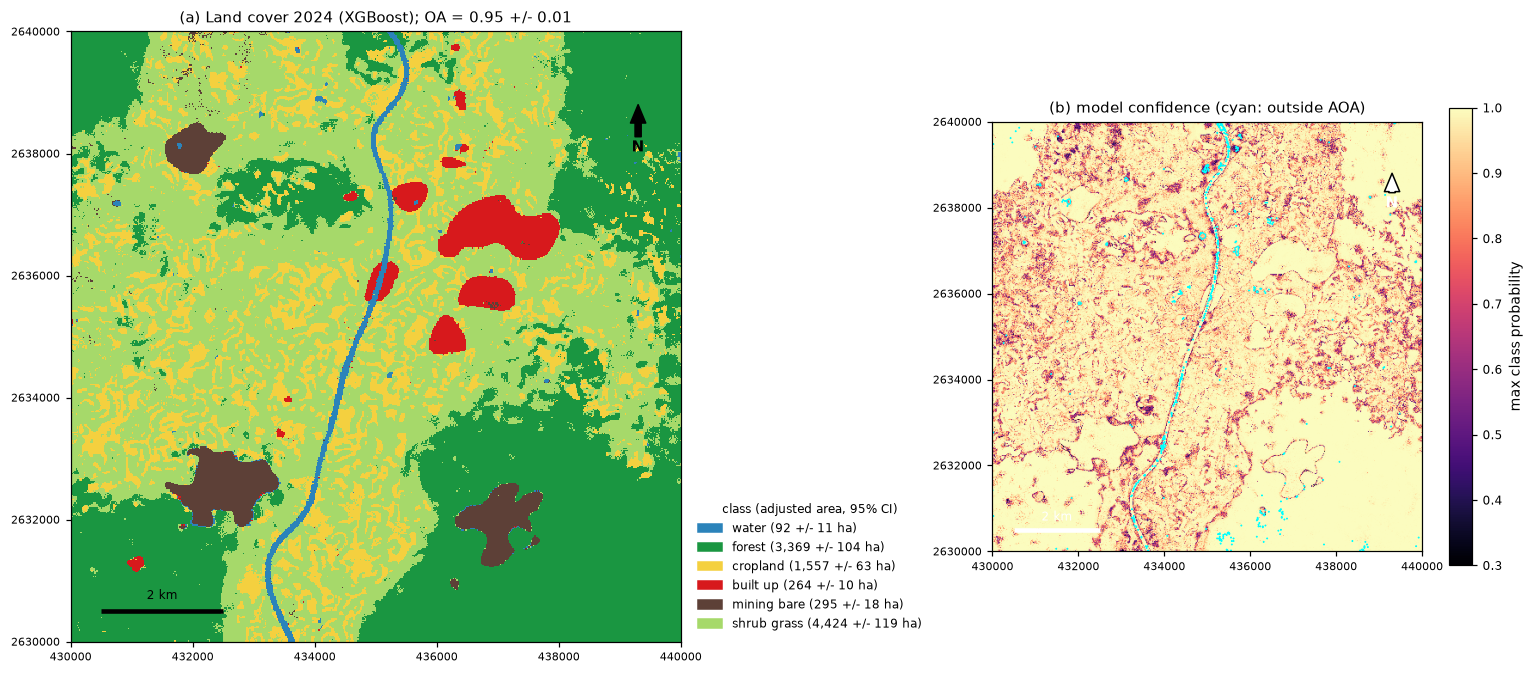

In [7]:
ext = ru.map_extent(T, (H, W)); cmap, norm = ru.categorical_cmap(config["class_colors"])
fig, axes = plt.subplots(1, 2, figsize=(14, 6.2), gridspec_kw={"width_ratios": [1.25, 1]})
axes[0].imshow(lc_map, cmap=cmap, norm=norm, extent=ext, interpolation="nearest")
axes[0].legend(handles=[Patch(color=c, label=f"{n.replace('_', ' ')} ({a:,.0f} +/- {e:,.0f} ha)") for c, n, a, e in
                        zip(config["class_colors"], CLASSES, summary["adjusted_area_ha"], summary["area_95CI_ha"])],
               loc="lower left", bbox_to_anchor=(1.01, 0.0), fontsize=8, title="class (adjusted area, 95% CI)", title_fontsize=8, frameon=False)
axes[0].set_title(f"(a) Land cover 2024 ({meta['model']}); OA = {summary.attrs['OA']:.2f} +/- {summary.attrs['OA_95CI']:.2f}")
im = axes[1].imshow(conf, cmap="magma", vmin=0.3, vmax=1, extent=ext)
axes[1].contour(np.linspace(ext[0], ext[1], W), np.linspace(ext[3], ext[2], H), (~aoa).astype(float), levels=[0.5], colors="cyan", linewidths=0.8)
fig.colorbar(im, ax=axes[1], shrink=0.75, label="max class probability"); axes[1].set_title("(b) model confidence (cyan: outside AOA)")
for ax in axes:
    ru.add_scalebar(ax, 2000, ext, color="k" if ax is axes[0] else "w"); ru.add_north_arrow(ax, color="k" if ax is axes[0] else "w")
    ax.ticklabel_format(style="plain"); ax.tick_params(labelsize=7)
plt.tight_layout(); fig.savefig(out / "figures/fig6_lulc_map.png", dpi=300, bbox_inches="tight"); plt.show()

## **6. Is the Confidence Layer Meaningful?**
A confidence map is only useful if low confidence really means more errors. Check this with the validation sample: sample accuracy per confidence bin (a reliability check of the map, weighted per sample).

In [8]:
vconf = conf[vr, vc]; bins = [0, 0.5, 0.6, 0.7, 0.8, 0.9, 1.01]
rel = pd.DataFrame({"bin": pd.cut(vconf, bins), "correct": val["map"].values == val["reference"].values}).groupby("bin", observed=True).agg(n=("correct", "size"), sample_accuracy=("correct", "mean"))
rel["share_of_map"] = pd.Series(pd.cut(conf.ravel(), bins)).value_counts(normalize=True).reindex(rel.index).values
rel.round(3)

,n,sample_accuracy,share_of_map
bin,,,
"(0.0, 0.5]",15,0.467,0.009
"(0.5, 0.6]",40,0.525,0.022
"(0.6, 0.7]",34,0.706,0.025
"(0.7, 0.8]",33,0.758,0.036
"(0.8, 0.9]",64,0.875,0.070
"(0.9, 1.01]",1089,0.983,0.838


## **7. Interpretation (Fig. 7)**
**Grouped permutation importance** permutes all features of a data source together, so correlated features cannot hide behind each other. It measures how much each source matters to the trained model, and it works for any model. For tree models, **SHAP** additionally shows which features drive each class.

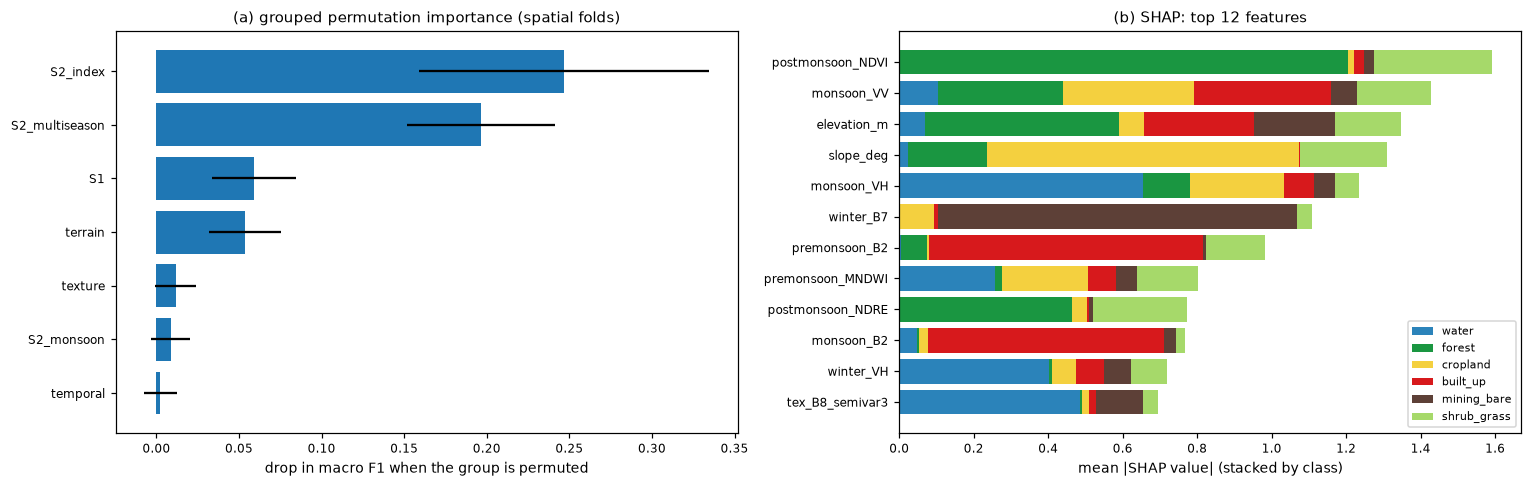

,mean drop in macro F1,s.d.
temporal,0.0024,0.0100
S2_monsoon,0.0086,0.0119
texture,0.0118,0.0125
terrain,0.0539,0.0218
S1,0.0591,0.0252
S2_multiseason,0.1964,0.0447
S2_index,0.2469,0.0879


In [9]:
Xtr, ytr, blocks = train[feats].values, train["class_id"].values, train["block"].values
from sklearn.model_selection import GroupKFold
from sklearn.base import clone
rng = np.random.default_rng(SEED); grp = {f: meta_g for f, meta_g in json.loads((PROJ / "data/feature_list.json").read_text())["groups"].items()}
src_groups = sorted({grp[f] for f in feats})
drops = {g: [] for g in src_groups}
for tr, te in GroupKFold(5).split(Xtr, ytr, blocks):                            # held-out spatial folds
    m = clone(model).fit(Xtr[tr], ytr[tr]); base = f1_score(ytr[te], m.predict(Xtr[te]), average="macro")
    for g in src_groups:
        idx = [i for i, f in enumerate(feats) if grp[f] == g]
        for _ in range(3):
            Xp = Xtr[te].copy(); Xp[:, idx] = Xp[rng.permutation(len(te))][:, idx]
            drops[g].append(base - f1_score(ytr[te], m.predict(Xp), average="macro"))
gimp = pd.DataFrame({"mean drop in macro F1": {g: np.mean(v) for g, v in drops.items()}, "s.d.": {g: np.std(v) for g, v in drops.items()}}).sort_values("mean drop in macro F1")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].barh(gimp.index, gimp.iloc[:, 0], xerr=gimp.iloc[:, 1], color="tab:blue"); axes[0].set_xlabel("drop in macro F1 when the group is permuted")
axes[0].set_title("(a) grouped permutation importance (spatial folds)")
if hasattr(est, "feature_importances_"):
    import shap
    sub = Xtr[rng.choice(len(Xtr), 200, replace=False)]
    sv = np.asarray(shap.TreeExplainer(est).shap_values(sub))                     # (n, features, classes) in shap >= 0.45
    sv = sv if sv.shape[1] == len(feats) else np.moveaxis(sv, 0, -1)
    mabs = np.abs(sv).mean(0)                                                      # (features, classes)
    top = np.argsort(mabs.sum(1))[-12:]
    left = np.zeros(len(top))
    for k in range(K):
        axes[1].barh([feats[i] for i in top], mabs[top, k], left=left, color=config["class_colors"][k], label=CLASSES[k]); left += mabs[top, k]
    axes[1].legend(fontsize=7); axes[1].set_xlabel("mean |SHAP value| (stacked by class)"); axes[1].set_title("(b) SHAP: top 12 features")
else:
    axes[1].axis("off"); axes[1].text(0.1, 0.5, "SHAP TreeExplainer needs a tree model;\nuse shap.KernelExplainer / PermutationExplainer otherwise", fontsize=9)
plt.tight_layout(); fig.savefig(out / "figures/fig7_interpretation.png", dpi=300, bbox_inches="tight"); plt.show()
gimp.round(4)

# **Part 2: Going Deeper**

## **8. Post-Processing: a Majority Filter**
Pixel classifiers produce "salt-and-pepper" noise. A 3x3 or 5x5 **majority (mode) filter** removes isolated pixels, but it also erodes thin objects (roads, rivers) and small ponds. Whether it helps must be **measured**.

The filtered map has different class boundaries from the strata of our validation sample. The Olofsson formulas assume strata = map classes, so we use the general **stratified estimator** of Stehman (2014): for each stratum h with N_h pixels and n_h samples, any proportion is estimated as sum_h N_h * ybar_h / N, with variance sum_h N_h^2 (1 - n_h/N_h) s_h^2 / n_h / N^2.

In [10]:
def majority_filter(lc, size, K):
    votes = np.stack([uniform_filter((lc == k).astype(np.float32), size) for k in range(K)])
    return votes.argmax(0).astype(np.uint8)

def stehman_proportion(yu, strata, N_h):
    """Estimate a population proportion and its SE from a stratified sample whose strata need not match the map."""
    N = sum(N_h.values()); est = var = 0.0
    for h, Nh in N_h.items():
        yh = yu[strata == h]; nh = len(yh)
        if nh == 0: continue
        est += Nh * yh.mean() / N
        if nh > 1: var += Nh ** 2 * (1 - nh / Nh) * yh.var(ddof=1) / nh / N ** 2
    return est, np.sqrt(var)

for size in [1, 3, 5]:
    m = lc_map if size == 1 else majority_filter(lc_map, size, K)
    oa, se = stehman_proportion((m[vr, vc] == val["reference"].values).astype(float), vstrat, counts)
    print(f"majority {size}x{size}: OA = {oa:.3f} +/- {1.96 * se:.3f} | TRUE OA {(m == truth).mean():.3f} | "
          f"water pixels {np.sum(m == 0):,} | built-up pixels {np.sum(m == 3):,}")

majority 1x1: OA = 0.952 +/- 0.012 | TRUE OA 0.949 | water pixels 2,913 | built-up pixels 6,781
majority 3x3: OA = 0.943 +/- 0.013 | TRUE OA 0.939 | water pixels 2,889 | built-up pixels 6,749
majority 5x5: OA = 0.899 +/- 0.016 | TRUE OA 0.905 | water pixels 2,843 | built-up pixels 6,790


## **9. The Results Paragraph (Generated from the Numbers)**
Generating text from saved results means the paper never disagrees with the tables, even after a re-run.

In [11]:
s = summary.set_index("class")
big = s["adjusted_area_ha"].idxmax(); worst_ua = s["UA"].idxmin(); worst_pa = s["PA"].idxmin()
diff = (s["adjusted_area_ha"] - s["mapped_area_ha"]) / s["mapped_area_ha"] * 100
text = (f"The {meta['model']} map (Fig. 6) had an overall accuracy of {summary.attrs['OA']:.3f} (95% CI +/- {summary.attrs['OA_95CI']:.3f}), estimated from an independent "
        f"stratified random sample of {len(val)} points (Table 4). User's accuracy was lowest for {worst_ua.replace('_', ' ')} ({s.loc[worst_ua, 'UA']:.2f} +/- {s.loc[worst_ua, 'UA_95CI']:.2f}) "
        f"and producer's accuracy was lowest for {worst_pa.replace('_', ' ')} ({s.loc[worst_pa, 'PA']:.2f} +/- {s.loc[worst_pa, 'PA_95CI']:.2f}). "
        f"Disagreement was mostly {'allocation' if allocation > quantity else 'quantity'} ({allocation:.3f}) rather than {'quantity' if allocation > quantity else 'allocation'} ({quantity:.3f}). "
        f"{big.replace('_', ' ').capitalize()} was the largest class ({s.loc[big, 'adjusted_area_ha']:,.0f} +/- {s.loc[big, 'area_95CI_ha']:,.0f} ha). "
        f"Bias correction changed class areas by {diff.abs().min():.1f}% to {diff.abs().max():.1f}% relative to pixel counting, the largest change being for "
        f"{diff.abs().idxmax().replace('_', ' ')} ({diff[diff.abs().idxmax()]:+.1f}%). {aoa.mean():.1%} of the study area was inside the area of applicability.")
(out / "results_paragraph.txt").write_text(text); print(text)

The XGBoost map (Fig. 6) had an overall accuracy of 0.952 (95% CI +/- 0.012), estimated from an independent stratified random sample of 1275 points (Table 4). User's accuracy was lowest for water (0.79 +/- 0.09) and producer's accuracy was lowest for forest (0.95 +/- 0.02). Disagreement was mostly allocation (0.042) rather than quantity (0.006). Shrub grass was the largest class (4,424 +/- 119 ha). Bias correction changed class areas by 0.5% to 21.3% relative to pixel counting, the largest change being for water (-21.3%). 99.7% of the study area was inside the area of applicability.


In [12]:
print("Project 1 outputs:")
for p in sorted(PROJ.rglob("*")):
    if p.is_file() and "__pycache__" not in str(p): print(f"  {p.as_posix():<70} {p.stat().st_size / 1e3:>8.0f} kB")

Project 1 outputs:
  project1_lulc/config.json                                                     1 kB
  project1_lulc/data/feature_list.json                                          6 kB
  project1_lulc/data/training_table.csv                                       492 kB
  project1_lulc/lulc_features.py                                                3 kB
  project1_lulc/models/final_model.joblib                                    1271 kB
  project1_lulc/models/final_model_meta.json                                    2 kB
  project1_lulc/outputs/figures/fig1_study_area.png                          4934 kB
  project1_lulc/outputs/figures/fig1b_true_vs_false_colour.png               5002 kB
  project1_lulc/outputs/figures/fig2_signatures.png                           687 kB
  project1_lulc/outputs/figures/fig4_model_comparison.png                     212 kB
  project1_lulc/outputs/figures/fig5_ablation.png                             146 kB
  project1_lulc/outputs/figures/fig6_lulc_map.

## **Practice Problems**
1. Re-run the validation with a **proportional** allocation (no minimum for rare classes). How wide do the CIs of UA for the rare classes become?
2. Compute the 95% CI of the **mining area** as a percentage of the study area, and write one sentence reporting it.
3. Mask the map to the AOA and report what share of the area remains mapped. How would we present the masked area in Fig. 6?
4. *(Advanced)* Bootstrap the validation sample within strata (1000 resamples) and compare the bootstrap 95% CI of OA with the analytical CI.

In [13]:
# Solution 1
prop = {k: max(2, int(round(len(val) * W_i[k]))) for k in range(K)}
r1, c1, s1 = ru.stratified_random_sample(lc_map, prop, seed=SEED + 7)
sum1, _ = ru.olofsson_accuracy(s1, truth[r1, c1], counts, PIXEL_HA, CLASSES)
print(pd.DataFrame({"n (minimum 75)": summary["sample_n"].values, "UA CI (minimum 75)": summary["UA_95CI"].round(3).values,
                    "n (proportional)": sum1["sample_n"].values, "UA CI (proportional)": sum1["UA_95CI"].round(3).values}, index=CLASSES))

             n (minimum 75)  UA CI (minimum 75)  n (proportional)  \
water                    75               0.093                15   
forest                  377               0.021               426   
cropland                172               0.025               194   
built_up                 75               0.037                35   
mining_bare              75               0.051                39   
shrub_grass             501               0.020               567   

             UA CI (proportional)  
water                       0.178  
forest                      0.019  
cropland                    0.034  
built_up                    0.056  
mining_bare                 0.070  
shrub_grass                 0.019  


In [14]:
# Solution 2
k = CLASSES.index("mining_bare"); A = H * W * PIXEL_HA
a, e = summary["adjusted_area_ha"].iloc[k], summary["area_95CI_ha"].iloc[k]
print(f"Mining and bare land covered {a:,.0f} ha (95% CI {a - e:,.0f}-{a + e:,.0f} ha), i.e. {100 * a / A:.2f}% +/- {100 * e / A:.2f}% of the study area.")

Mining and bare land covered 295 ha (95% CI 277-312 ha), i.e. 2.95% +/- 0.18% of the study area.


In [15]:
# Solution 3
print(f"inside AOA: {aoa.mean():.1%} of the area. Show the outside part in grey with a legend entry 'outside area of applicability'.")
masked = np.where(aoa, lc_map, 255)

inside AOA: 99.7% of the area. Show the outside part in grey with a legend entry 'outside area of applicability'.


In [16]:
# Solution 4
rng4 = np.random.default_rng(0); boots = []
mv, rv, sv_ = val["map"].values, val["reference"].values, vstrat
for _ in range(1000):
    idx = np.concatenate([rng4.choice(np.flatnonzero(sv_ == h), (sv_ == h).sum(), replace=True) for h in np.unique(sv_)])
    boots.append(ru.olofsson_accuracy(mv[idx], rv[idx], counts, PIXEL_HA, CLASSES)[0].attrs["OA"])
lo, hi = np.percentile(boots, [2.5, 97.5])
print(f"bootstrap 95% CI of OA: {lo:.3f}-{hi:.3f} | analytical: {summary.attrs['OA'] - summary.attrs['OA_95CI']:.3f}-{summary.attrs['OA'] + summary.attrs['OA_95CI']:.3f}")

bootstrap 95% CI of OA: 0.939-0.963 | analytical: 0.940-0.964


## **Key References**
- Olofsson, P., Foody, G. M., Herold, M., Stehman, S. V., Woodcock, C. E., & Wulder, M. A. (2014). Good practices for estimating area and assessing accuracy of land change. *Remote Sensing of Environment*, 148, 42-57.
- Stehman, S. V. (2014). Estimating area and map accuracy for stratified random sampling when the strata are different from the map classes. *International Journal of Remote Sensing*, 35(13), 4923-4939.
- Stehman, S. V., & Foody, G. M. (2019). Key issues in rigorous accuracy assessment of land cover products. *Remote Sensing of Environment*, 231, 111199.
- Meyer, H., & Pebesma, E. (2021). Predicting into unknown space? Estimating the area of applicability of spatial prediction models. *Methods in Ecology and Evolution*, 12(9), 1620-1633.
- Lundberg, S. M. et al. (2020). From local explanations to global understanding with explainable AI for trees. *Nature Machine Intelligence*, 2, 56-67.
- Pontius, R. G., & Millones, M. (2011). Death to Kappa: birth of quantity disagreement and allocation disagreement for accuracy assessment. *International Journal of Remote Sensing*, 32(15), 4407-4429.